In [1]:
## -- CHECK FOR 3rd PARTY LIBRARIES --
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    import skrub
except:
    %pip install -q pytorch-tabnet
    %pip install -q skrub

    from pytorch_tabnet.tab_model import TabNetClassifier
    import skrub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.5/500.5 kB 8.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [3]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
# import tensorflow as tf

import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.calibration import CalibrationDisplay

import warnings

In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
# tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

CLASSIC  GREEN   YELLOW 


In [5]:
# ## -- Load Data Kaggle--
# PATH = '/kaggle/input/competitions/playground-series-s6e3/'
# submit = pd.read_csv(PATH+'sample_submission.csv')
# train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
# test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

# ORIG_PATH = '/kaggle/input/datasets/sylvesterdalmeida/telco-customer-churn/'
# orig = pd.read_csv(ORIG_PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)

# TARGET = train.columns[-1]
# NUMS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
# CATS   = [c for c in train.columns if c not in NUMS+[TARGET, 'id']]
# BASE   = NUMS + CATS

# train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})
# orig[TARGET]  = orig[TARGET].map({'Yes': 1, 'No': 0})

# for (name, df) in dict(Train=train, Test=test, Original=orig).items():
#     print(f"{name} shape: {df.shape}")

# print(f"\nTotal Numerical: {len(NUMS)}")
# print(f"Total Categorical: {len(CATS)}")
# print(f"Total base features: {len(BASE)}")

In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e3/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
    test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

    ORIG_PATH = '/kaggle/input/datasets/sylvesterdalmeida/telco-customer-churn/'
    orig = pd.read_csv(ORIG_PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e3 | Customer Churn/_churn_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop('id', axis=1)
    test = pd.read_csv(PATH+'test.csv').drop('id', axis=1)
    orig = pd.read_csv(PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]
NUMS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATS   = [c for c in train.columns if c not in NUMS+[TARGET, 'id']]
BASE   = NUMS + CATS

train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})
orig[TARGET]  = orig[TARGET].map({'Yes': 1, 'No': 0})

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")

Train shape: (594194, 20)
Test shape: (254655, 19)
Original shape: (7043, 20)

Total Numerical: 3
Total Categorical: 16


In [7]:
display(train.head())
train.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [8]:
train[NUMS].describe()

,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000
mean,36.577258,65.866223,2494.377057
std,25.061922,31.067444,2353.916710
min,1.000000,18.250000,18.800000
25%,12.000000,29.900000,639.650000
50%,35.000000,74.100000,1433.650000
75%,62.000000,90.800000,4263.800000
max,72.000000,118.750000,8684.800000


In [9]:
## -- FIX ORIGINAL COLUMN --
orig['TotalCharges'] = orig['TotalCharges'].replace(' ', np.nan).astype(float)
orig['TotalCharges'] = orig['TotalCharges'].fillna(orig['TotalCharges'].median())

display(orig.head())
orig.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


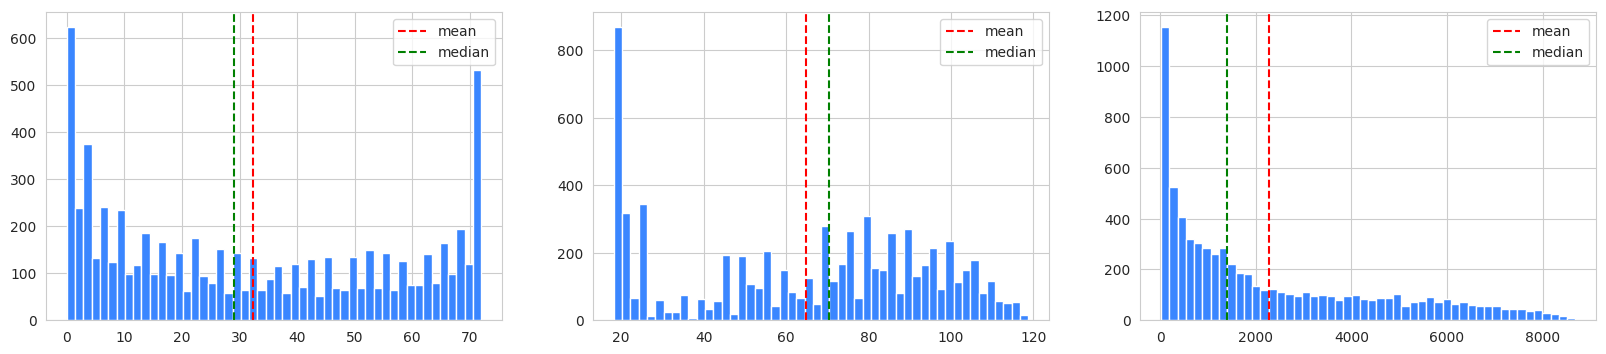

In [10]:
plt.figure(figsize=(20, 4))
for i, col in enumerate(NUMS):
    plt.subplot(1, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.legend()

plt.show()

In [11]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
Train,72,1921,31910,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Original,73,1585,6531,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Test,72,1875,24995,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4


## FEATURE ENGINEERING

In [12]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []

In [13]:
for col in ['TotalCharges']:
    print(f"\nEXTRACTING ROUNDS... ", end='')
    # for r in [-3, -2, -1, 0, 1]:
    #     r_n = f"{col}_round_{r}"
    #     print(r_n+', ', end='')
    #     train[r_n] = train[col].round(r).astype('int32')
    #     test[r_n]  = test[col].round(r).astype('int32')
    #     orig[r_n]  = orig[col].round(r).astype('int32')
    #     ## -- Drop irrelevant features --
    #     if train[r_n].nunique() <= 2:
    #         train = train.drop([r_n], axis=1)
    #         test  = test.drop([r_n], axis=1)
    #         orig  = orig.drop([r_n], axis=1)
    #     elif train[r_n].nunique() == train[col].nunique():
    #         train = train.drop([r_n], axis=1)
    #         test  = test.drop([r_n], axis=1)
    #         orig  = orig.drop([r_n], axis=1)
    #     else:
    #         ROUNDS.append(r_n)

    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-3, -2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)

    print(f"\nCREATING E_BINS... ", end='')
    for b in [400]: # 100, 500, 1000
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)

    print(f"\nQUANTILE BINNING... ", end='')
    for q in [1000]: # 100, 500, 1000
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS)}')
print(f"✅ TOTAL DIGITS EXTRACTED: {len(DIGITS)}")
print(f"✅ TOTAL EQUAL E_BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE E_BINS: {len(Q_BINS)}")


EXTRACTING ROUNDS... 
EXTRACTING DIGITS... TotalCharges_digit_-3, TotalCharges_digit_-2, TotalCharges_digit_-1, TotalCharges_digit_0, TotalCharges_digit_1, TotalCharges_digit_2, 
CREATING E_BINS... TotalCharges_bin_400, 
QUANTILE BINNING... TotalCharges_Qbin_1000, 
✅ TOTAL ROUND FEATURES: 0
✅ TOTAL DIGITS EXTRACTED: 6
✅ TOTAL EQUAL E_BINS: 1
✅ TOTAL QUANTILE E_BINS: 1


In [14]:
for col in ['MonthlyCharges']:
    # print(f"\nROUNDING FEATURES... ", end='')
    # for r in [-2, -1, 0]:
    #     r_n = f"{col}_round_{r}"
    #     print(r_n+', ', end='')
    #     train[r_n] = train[col].round(r).astype('int32')
    #     test[r_n]  = test[col].round(r).astype('int32')
    #     orig[r_n]  = orig[col].round(r).astype('int32')
    #     ## -- Drop irrelevant features --
    #     if train[r_n].nunique() <= 2:
    #         train = train.drop([r_n], axis=1)
    #         test  = test.drop([r_n], axis=1)
    #         orig  = orig.drop([r_n], axis=1)
    #     elif train[r_n].nunique() == train[col].nunique():
    #         train = train.drop([r_n], axis=1)
    #         test  = test.drop([r_n], axis=1)
    #         orig  = orig.drop([r_n], axis=1)
    #     else:
    #         ROUNDS.append(r_n)

    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)

    print(f"\nEQUAL BINNING... ", end='')
    for b in [100]: # 50, 100, 400
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        # Fit on train data and transform both train and test
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)

    print(f"\nQUANTILE BINNING... ", end='')
    for q in [500]: # 50, 100, 400
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f"✅ TOTAL DIGITS: {len(DIGITS)}")
print(f'✅ TOTAL ROUNDs: {len(ROUNDS)}')
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS)}")


EXTRACTING DIGITS... MonthlyCharges_digit_-2, MonthlyCharges_digit_-1, MonthlyCharges_digit_0, MonthlyCharges_digit_1, MonthlyCharges_digit_2, 
EQUAL BINNING... MonthlyCharges_bin_100, 
QUANTILE BINNING... MonthlyCharges_Qbin_500, 
✅ TOTAL DIGITS: 11
✅ TOTAL ROUNDs: 0
✅ TOTAL EQUAL BINS: 2
✅ TOTAL QUANTILE BINS: 2


In [15]:
for col in ['tenure']:
    # print(f"\nEXTRACTING ROUNDS... ", end='')
    # for r in [-1]:
    #     r_n = f"{col}_round_{r}"
    #     print(r_n+', ', end='')
    #     train[r_n] = train[col].round(r).astype('int32')
    #     test[r_n]  = test[col].round(r).astype('int32')
    #     orig[r_n]  = orig[col].round(r).astype('int32')
    #     ## -- Drop irrelevant features --
    #     if train[r_n].nunique() <= 2:
    #         train = train.drop([r_n], axis=1)
    #         test  = test.drop([r_n], axis=1)
    #         orig  = orig.drop([r_n], axis=1)
    #     elif train[r_n].nunique() == train[col].nunique():
    #         train = train.drop([r_n], axis=1)
    #         test  = test.drop([r_n], axis=1)
    #         orig  = orig.drop([r_n], axis=1)
    #     else:
    #         ROUNDS.append(r_n)

    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-1, 0]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)

    print(f"\nEQUAL BINNING... ", end='')
    for b in [10, 50]: # 10, 50
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        # Fit on train data and transform both train and test
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)

    print(f"\nQUANTILE BINNING... ", end='')
    for q in [10, 50]: # 10, 50
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS):<10}')
print(f"✅ TOTAL DIGITS FEATURES: {len(DIGITS):<10}")
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS):<10}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS):<10}")


EXTRACTING DIGITS... tenure_digit_-1, tenure_digit_0, 
EQUAL BINNING... tenure_bin_10, tenure_bin_50, 
QUANTILE BINNING... tenure_Qbin_10, tenure_Qbin_50, 
✅ TOTAL ROUND FEATURES: 0         
✅ TOTAL DIGITS FEATURES: 13        
✅ TOTAL EQUAL BINS: 4         
✅ TOTAL QUANTILE BINS: 4         


In [16]:
ALL_ROUND_BINS = ROUNDS + E_BINS + Q_BINS

train[ALL_ROUND_BINS].nunique().sort_values()

tenure_bin_10               10
tenure_Qbin_10              10
tenure_Qbin_50              42
tenure_bin_50               50
MonthlyCharges_bin_100     100
TotalCharges_bin_400       396
MonthlyCharges_Qbin_500    433
TotalCharges_Qbin_1000     998
dtype: int64

In [17]:
LOW_100_UNIQUE = []

for col in ALL_ROUND_BINS:
    if train[col].nunique() < 100:
        LOW_100_UNIQUE.append(col)

print(f"Cats with ~100 unique: {len(LOW_100_UNIQUE)}")
print()
TOP_100_UNIQUE = [c for c in ALL_ROUND_BINS if c not in LOW_100_UNIQUE]
print(f"Cats with +100 unique: {len(TOP_100_UNIQUE)}")

Cats with ~100 unique: 4

Cats with +100 unique: 4


In [18]:
## -- Arithmetic interaction --
for df in [train, test, orig]:
    df['_MonthlyCharges_/_TotalCharges'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
    df['_TotalCharges_/_tenure']  = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')
    df['_Monthly_to_avg_ratio'] = (df['MonthlyCharges'] / (df['_TotalCharges_/_tenure'] + 1e-6)).astype('float32')
    df['_TotalCharges_/_MonthlyCharges']  = (df['TotalCharges'] / (df['MonthlyCharges'] + 1e-6)).astype('float32')
    df['_tenure_sq'] = (df['tenure'] ** 2).astype("float32")

ARITHMETIC = ['_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure',
              '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq']

train[ARITHMETIC].head(3)

,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq
0,0.036339,57.029308,1.053844,27.518303,841.0
1,0.018395,65.141380,1.066910,54.362591,3364.0
2,0.017188,100.712929,0.996893,58.180775,3364.0


In [19]:
## -- Cyclic encoding --
CYCLICS = []

for col in ['MonthlyCharges', 'TotalCharges']:
    for p in [12, 30]:
        n_s = f'{col}_sin_{p}'
        n_c = f'{col}_cos_{p}'
        train[n_s] = np.sin(2 * np.pi * train['MonthlyCharges'] / p).astype('float32')
        train[n_c] = np.cos(2 * np.pi * train['MonthlyCharges'] / p).astype('float32')

        test[n_s] = np.sin(2 * np.pi * test['MonthlyCharges'] / p).astype('float32')
        test[n_c] = np.cos(2 * np.pi * test['MonthlyCharges'] / p).astype('float32')

        orig[n_s] = np.sin(2 * np.pi * orig['MonthlyCharges'] / p).astype('float32')
        orig[n_c] = np.cos(2 * np.pi * orig['MonthlyCharges'] / p).astype('float32')

        CYCLICS += [n_s, n_c]

print(f"Cylcic Features created: {len(CYCLICS)}")
train[CYCLICS].head(3)

Cylcic Features created: 8


,MonthlyCharges_sin_12,MonthlyCharges_cos_12,MonthlyCharges_sin_30,MonthlyCharges_cos_30,TotalCharges_sin_12,TotalCharges_cos_12,TotalCharges_sin_30,TotalCharges_cos_30
0,0.052336,0.998630,0.020942,0.999781,0.052336,0.998630,0.020942,0.999781
1,-0.965926,0.258819,0.913545,-0.406737,-0.965926,0.258819,0.913545,-0.406737
2,0.743145,-0.669131,0.821149,-0.570714,0.743145,-0.669131,0.821149,-0.570714


In [20]:
# ## -- FREQUENCY ENCODING --
# NUMS_FREQ = []
# print(f"\nCREATING FREQUENCIES... ", end='')
# for col in NUMS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_FREQ'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     NUMS_FREQ.append(n)

# print()
# print(f"✅ TOTAL FREQUENCY FEEATURES: {len(NUMS_FREQ)}")

In [21]:
# INTER = []
# TOP_CATS = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

# for c1, c2 in tqdm(list(itertools.combinations(BASE, 2)), desc='Pairwise'): # +DIGITS
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_CATS[:4], 3)), desc='Triplewise'):
#     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(TOP_PREDICTORS, OTHER_PREDICTORS)), desc='One-To-Many Pairwise'):
#     new_col = f"{c1}-|-{c2}"
#     train[new_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[new_col] = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[new_col] = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(new_col)

# print(f"TOTAL INTERACTION FEATURES: {len(INTER)}")

In [22]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [23]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [24]:
train, test, _, ORIG_COLS = orig_TE_data_propagate(
    orig,
    train,
    test,
    train.iloc[:500],
    features=BASE, #+ROUNDS,
    target=TARGET,
    aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
    fill_nan=True,
)

TE_merging:   0%|          | 0/19 [00:00<?, ?it/s]

In [25]:
## -- DUPLICATE 'tunure' AS CATEGORICAL --
for df in [train, test, orig]:
    df['cat_tenure'] = df['tenure'].values

print(f"- DUPLICATE 'tenure' FEATURE AS CATEGORICAL -")

- DUPLICATE 'tenure' FEATURE AS CATEGORICAL -


In [26]:
# FEATURES = CATS + ['cat_tenure'] + DIGITS + LOW_100_UNIQUE + TOP_100_UNIQUE + \
#            NUMS + NUMS_FREQ + CYCLICS + ARITHMETIC + ORIG_COLS

# train = train[FEATURES+[TARGET]].copy()
# test  = test[FEATURES].copy()

# print('Total Features:', len(FEATURES))

# train.head(3)

In [27]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 92


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_digit_-3,TotalCharges_digit_-2,TotalCharges_digit_-1,TotalCharges_digit_0,TotalCharges_digit_1,TotalCharges_digit_2,TotalCharges_bin_400,TotalCharges_Qbin_1000,MonthlyCharges_digit_-2,MonthlyCharges_digit_-1,MonthlyCharges_digit_0,MonthlyCharges_digit_1,MonthlyCharges_digit_2,MonthlyCharges_bin_100,MonthlyCharges_Qbin_500,tenure_digit_-1,tenure_digit_0,tenure_bin_10,tenure_bin_50,tenure_Qbin_10,tenure_Qbin_50,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq,MonthlyCharges_sin_12,MonthlyCharges_cos_12,MonthlyCharges_sin_30,MonthlyCharges_cos_30,TotalCharges_sin_12,TotalCharges_cos_12,TotalCharges_sin_30,TotalCharges_cos_30,OTE_tenure_mean,OTE_tenure_std,OTE_MonthlyCharges_mean,OTE_MonthlyCharges_std,OTE_TotalCharges_mean,OTE_TotalCharges_std,OTE_gender_mean,OTE_gender_std,OTE_SeniorCitizen_mean,OTE_SeniorCitizen_std,OTE_Partner_mean,OTE_Partner_std,OTE_Dependents_mean,OTE_Dependents_std,OTE_PhoneService_mean,OTE_PhoneService_std,OTE_MultipleLines_mean,OTE_MultipleLines_std,OTE_InternetService_mean,OTE_InternetService_std,OTE_OnlineSecurity_mean,OTE_OnlineSecurity_std,OTE_OnlineBackup_mean,OTE_OnlineBackup_std,OTE_DeviceProtection_mean,OTE_DeviceProtection_std,OTE_TechSupport_mean,OTE_TechSupport_std,OTE_StreamingTV_mean,OTE_StreamingTV_std,OTE_StreamingMovies_mean,OTE_StreamingMovies_std,OTE_Contract_mean,OTE_Contract_std,OTE_PaperlessBilling_mean,OTE_PaperlessBilling_std,OTE_PaymentMethod_mean,OTE_PaymentMethod_std,cat_tenure
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,0,1,6,5,3,8,5,75,538,0,6,0,1,0,41,133,2,9,3,19,4,19,0.036339,57.029308,1.053844,27.518303,841.0,0.052336,0.998630,0.020942,0.999781,0.052336,0.998630,0.020942,0.999781,0.208333,0.408966,1.000000,0.000000,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.399288,0.489831,0.225021,0.417682,0.151663,0.358782,0.335231,0.472155,0.336804,0.472702,0.112695,0.316327,0.335651,0.472274,0.191067,0.393264,29
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,0,3,7,7,8,2,0,173,716,0,6,9,5,0,50,159,5,8,8,40,7,32,0.018395,65.141380,1.066910,54.362591,3364.0,-0.965926,0.258819,0.913545,-0.406737,-0.965926,0.258819,0.913545,-0.406737,0.164179,0.373234,0.272727,0.467099,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.215315,0.411125,0.391276,0.488115,0.151663,0.358782,0.300702,0.458648,0.336804,0.472702,0.028319,0.165930,0.163301,0.369704,0.152431,0.359556,58
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,0,5,8,4,1,3,5,268,863,1,0,0,4,0,81,366,5,8,8,40,7,32,0.017188,100.712929,0.996893,58.180775,3364.0,0.743145,-0.669131,0.821149,-0.570714,0.743145,-0.669131,0.821149,-0.570714,0.164179,0.373234,0.000000,0.000000,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.312791,0.463677,0.267096,0.442478,0.286099,0.452012,0.418928,0.493463,0.417667,0.493245,0.215315,0.411125,0.391276,0.488115,0.416355,0.493025,0.300702,0.458648,0.299414,0.458085,0.427097,0.494720,0.335651,0.472274,0.452854,0.497878,58


# ML TRAINING

In [28]:
def Trainer_CV(
    model_name, params, train_df, test_df, features, target, kf,
    metrics=['log_loss'], cats=None, dim_cols=None, show_df=True,
    ):

    print(f"\n==================== Starting Cross-Validation for {model_name} ====================")
    start = time()

    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], train_df[target])):
        print(f"\n ##### FOLD {idx + 1}/{kf.n_splits} | ", end='')

        # Split data for the current fold
        X_train, X_val = train_df.loc[train_idx, features], train_df.loc[val_idx, features]
        y_train, y_val = train_df.loc[train_idx, target], train_df.loc[val_idx, target]

        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_val, X_test, ORIG_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_val,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['count', 'std'], # mean, median, count, std, nunique, max, min
        #     fill_nan=True,
        # )

        # for c in DIGITS:
        #     cme = CategoryMeanTransformer(cat_cols=[c])
        #     X_train[c] = cme.fit_transform(X_train[[c]], y_train).fillna(-1)
        #     X_val[c]   = cme.transform(X_val[[c]]).fillna(-1)
        #     X_test[c]  = cme.transform(X_test[[c]]).fillna(-1)

        # # cme_features = NUMS
        # # cme_cols = []
        # # print(f"CategoryMeanEncoding: {len(cme_features)} | ", end='')
        # for c in NUMS:
        #     # n = f"cme_{c}"
        #     cme_1 = CategoryMeanTransformer(cat_cols=[c])
        #     X_train[c] = cme_1.fit_transform(X_train[[c]], y_train).fillna(-1)
        #     X_val[c]   = cme_1.transform(X_val[[c]]).fillna(-1)
        #     X_test[c]  = cme_1.transform(X_test[[c]]).fillna(-1)

        #     scaler = StandardScaler()
        #     X_train[c] = scaler.fit_transform(X_train[[c]], y_train)
        #     X_val[c]   = scaler.transform(X_val[[c]])
        #     X_test[c]  = scaler.transform(X_test[[c]])
        #     # cme_cols.append(n)

        ## -- TE Opt1. -> Using CUSTOM -- 
        TE = TargetEncoder(NUMS, cv=5, smooth='auto', aggs=['mean'], drop_original=False)
        X_train = TE.fit_transform(X_train, y_train)
        X_val   = TE.transform(X_val)
        X_test  = TE.transform(X_test)

        TE = TargetEncoder(TOP_100_UNIQUE, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = TE.fit_transform(X_train, y_train)
        X_val   = TE.transform(X_val)
        X_test  = TE.transform(X_test)

        # tv_enc  = skrub.TableVectorizer(n_jobs=os.cpu_count())
        # X_train = tv_enc.fit_transform(X_train)
        # X_val   = tv_enc.transform(X_val)
        # X_test  = tv_enc.transform(X_test)

        ## ===============================================================================

        ## -- Define categorical features for categorical embeddings
        combined = pd.concat([X_train, X_val, X_test])
        for col in dim_cols:
            l_enc = LabelEncoder()
            l_enc.fit(combined[col].astype(str))

            X_train[col] = l_enc.transform(X_train[col].astype(str))
            X_val[col]   = l_enc.transform(X_val[col].astype(str))
            X_test[col]  = l_enc.transform(X_test[col].astype(str))

        new_features = X_train.columns.tolist()

        categorical_dims = { col: X_train[col].nunique() for col in dim_cols }
        
        cat_cols_in_features = [ f for f in dim_cols if f in new_features ]
        cat_idxs = [ new_features.index(f) for f in dim_cols ]
        cat_dims = [ categorical_dims[f] for f in new_features if f in dim_cols ]

        print(f"X_train shape: {X_train.shape} #####")
        print()
        print('cat_idxs:', cat_idxs)
        print('cat_dims:', cat_dims)
        ## ===============================================================================

        if show_df:
            display(X_train.head(3))

        model = TabNetClassifier(**params, cat_idxs=cat_idxs, cat_dims=cat_dims)
        # display(model)
        # break

        model.fit(
            X_train.to_numpy(), y_train.to_numpy(),
            eval_set=[(X_val.to_numpy(), y_val.to_numpy())],
            eval_metric=metrics,
            max_epochs=30, patience=5,
            # batch_size=2048,
            # virtual_batch_size=512,
             drop_last=False,
        )

        ## -- Predict on validation and test sets --
        oof_preds[val_idx] = model.predict_proba(X_val.to_numpy())[:, 1].ravel()
        test_preds += model.predict_proba(X_test.to_numpy())[:, 1].ravel()

        ## -- Calculate and print fold score --
        fold_auc = roc_auc_score(y_val.to_numpy(), oof_preds[val_idx])
        fold_scores.append(fold_auc)
        print(f"{YELLOW}• FOLD {idx + 1} AUC: {fold_auc:.5f} {RESET}")

        ## -- Clean up memory --
        del X_train, y_train, y_val, X_test
        gc.collect()
        torch.cuda.empty_cache()

    ## -- Average the test predictions --
    test_preds /= kf.n_splits

    ## -- Print final cross-validation results --
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f" • FOLD {i+1} AUC: {score:.5f}")

    ## -- Calculate final out-of-fold AUC --
    oof_auc = np.round(roc_auc_score(train_df[target], oof_preds), 6)

    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_auc}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} \u00b1 {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_auc,
        'model': model,
        'val_data': X_val,
        'columns': X_val.columns,
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [29]:
all_model_predictions = {}

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

N_SPLITS = 10
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

kf

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

In [30]:
x_sample, x_sample2 = train_test_split(train, train_size=0.2, stratify=train[TARGET], random_state=0)
x_sample.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_digit_-3,TotalCharges_digit_-2,TotalCharges_digit_-1,TotalCharges_digit_0,TotalCharges_digit_1,TotalCharges_digit_2,TotalCharges_bin_400,TotalCharges_Qbin_1000,MonthlyCharges_digit_-2,MonthlyCharges_digit_-1,MonthlyCharges_digit_0,MonthlyCharges_digit_1,MonthlyCharges_digit_2,MonthlyCharges_bin_100,MonthlyCharges_Qbin_500,tenure_digit_-1,tenure_digit_0,tenure_bin_10,tenure_bin_50,tenure_Qbin_10,tenure_Qbin_50,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq,MonthlyCharges_sin_12,MonthlyCharges_cos_12,MonthlyCharges_sin_30,MonthlyCharges_cos_30,TotalCharges_sin_12,TotalCharges_cos_12,TotalCharges_sin_30,TotalCharges_cos_30,OTE_tenure_mean,OTE_tenure_std,OTE_MonthlyCharges_mean,OTE_MonthlyCharges_std,OTE_TotalCharges_mean,OTE_TotalCharges_std,OTE_gender_mean,OTE_gender_std,OTE_SeniorCitizen_mean,OTE_SeniorCitizen_std,OTE_Partner_mean,OTE_Partner_std,OTE_Dependents_mean,OTE_Dependents_std,OTE_PhoneService_mean,OTE_PhoneService_std,OTE_MultipleLines_mean,OTE_MultipleLines_std,OTE_InternetService_mean,OTE_InternetService_std,OTE_OnlineSecurity_mean,OTE_OnlineSecurity_std,OTE_OnlineBackup_mean,OTE_OnlineBackup_std,OTE_DeviceProtection_mean,OTE_DeviceProtection_std,OTE_TechSupport_mean,OTE_TechSupport_std,OTE_StreamingTV_mean,OTE_StreamingTV_std,OTE_StreamingMovies_mean,OTE_StreamingMovies_std,OTE_Contract_mean,OTE_Contract_std,OTE_PaperlessBilling_mean,OTE_PaperlessBilling_std,OTE_PaymentMethod_mean,OTE_PaymentMethod_std,cat_tenure
235601,Female,0,Yes,Yes,25,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Bank transfer (automatic),74.75,1867.70,0,1,8,6,7,7,0,85,581,0,7,4,7,5,56,196,2,5,3,16,4,17,0.040022,74.708000,1.000562,24.985952,625.0,0.991445,0.130526,0.052336,-0.998630,0.991445,0.130526,0.052336,-0.998630,0.291139,0.457190,0.30,0.483046,0.0,0.0,0.269209,0.443612,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.418928,0.493463,0.146112,0.353306,0.399288,0.489831,0.391276,0.488115,0.416355,0.493025,0.335231,0.472155,0.336804,0.472702,0.427097,0.494720,0.163301,0.369704,0.167098,0.373185,25
3864,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.90,70.90,1,0,0,7,0,9,0,2,40,0,7,0,9,0,52,178,0,1,0,0,0,0,1.000000,70.899933,1.000001,1.000000,1.0,-0.544639,0.838671,0.756995,-0.653421,-0.544639,0.838671,0.756995,-0.653421,0.619902,0.485807,0.40,0.547723,1.0,0.0,0.261603,0.439570,0.236062,0.424697,0.329580,0.470125,0.312791,0.463677,0.267096,0.442478,0.250442,0.433332,0.418928,0.493463,0.417667,0.493245,0.399288,0.489831,0.391276,0.488115,0.416355,0.493025,0.335231,0.472155,0.336804,0.472702,0.427097,0.494720,0.335651,0.472274,0.191067,0.393264,1
86204,Male,0,Yes,No,45,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,Yes,Credit card (automatic),99.30,4698.05,0,4,6,9,8,0,5,215,782,0,9,9,3,0,80,355,4,5,6,30,5,25,0.021136,104.401108,0.951139,47.311680,2025.0,0.987688,-0.156434,0.929776,-0.368125,0.987688,-0.156434,0.929776,-0.368125,0.098361,0.300273,0.25,0.500000,0.0,0.0,0.261603,0.439570,0.236062,0.424697,0.196649,0.397523,0.312791,0.463677,0.267096,0.442478,0.286099,0.452012,0.418928,0.493463,0.417667,0.493245,0.399288,0.489831,0.391276,0.488115,0.151663,0.358782,0.300702,0.458648,0.299414,0.458085,0.112695,0.316327,0.335651,0.472274,0.152431,0.359556,45


In [31]:
version_name = 'tabnetV3_'

USE_FULL_TRAIN = True
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

if all_model_predictions:
    all_model_predictions.clear()

params = {
    # 'n_d': 8,
    # 'n_a': 8,
    # 'n_steps': 3,
    # 'gamma': 1.3,
    # 'n_independent': 2,
    # 'n_shared': 2,
    # 'epsilon': 1e-15,
    # 'lambda_sparse': 1e-3,
    # 'optimizer_fn': optim.Adam,
    # 'cat_emb_dim': 1,
    'optimizer_params': {'lr': 0.04},#, 'weight_decay': 0.01
    # 'scheduler_fn': torch.optim.lr_scheduler.ReduceLROnPlateau,
    # 'scheduler_params': dict(mode='min', factor=0.5, patience=5),
    # 'mask_type': 'sparsemax',
    'verbose': 1,
    'seed': SEED,
}

for metric in ['logloss', 'auc']: # , 'auc', 
    # params['seed'] = seeder
    n = version_name + str(metric)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=params,
        train_df=train_data,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        metrics=[metric],
        dim_cols=CATS+LOW_100_UNIQUE+['cat_tenure'], # + LOW_100_UNIQUE, # + DIGITS + 
    )


==================== Starting Cross-Validation for tabnetV3_logloss ====================

 ##### FOLD 1/10 | X_train shape: (534774, 95) #####

cat_idxs: [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 32, 33, 34, 35, 87]
cat_dims: [2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 4, 10, 50, 10, 42, 72]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TotalCharges_digit_-3,TotalCharges_digit_-2,TotalCharges_digit_-1,TotalCharges_digit_0,TotalCharges_digit_1,TotalCharges_digit_2,MonthlyCharges_digit_-2,MonthlyCharges_digit_-1,MonthlyCharges_digit_0,MonthlyCharges_digit_1,MonthlyCharges_digit_2,tenure_digit_-1,tenure_digit_0,tenure_bin_10,tenure_bin_50,tenure_Qbin_10,tenure_Qbin_50,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq,MonthlyCharges_sin_12,MonthlyCharges_cos_12,MonthlyCharges_sin_30,MonthlyCharges_cos_30,TotalCharges_sin_12,TotalCharges_cos_12,TotalCharges_sin_30,TotalCharges_cos_30,OTE_tenure_mean,OTE_tenure_std,OTE_MonthlyCharges_mean,OTE_MonthlyCharges_std,OTE_TotalCharges_mean,OTE_TotalCharges_std,OTE_gender_mean,OTE_gender_std,OTE_SeniorCitizen_mean,OTE_SeniorCitizen_std,OTE_Partner_mean,OTE_Partner_std,OTE_Dependents_mean,OTE_Dependents_std,OTE_PhoneService_mean,OTE_PhoneService_std,OTE_MultipleLines_mean,OTE_MultipleLines_std,OTE_InternetService_mean,OTE_InternetService_std,OTE_OnlineSecurity_mean,OTE_OnlineSecurity_std,OTE_OnlineBackup_mean,OTE_OnlineBackup_std,OTE_DeviceProtection_mean,OTE_DeviceProtection_std,OTE_TechSupport_mean,OTE_TechSupport_std,OTE_StreamingTV_mean,OTE_StreamingTV_std,OTE_StreamingMovies_mean,OTE_StreamingMovies_std,OTE_Contract_mean,OTE_Contract_std,OTE_PaperlessBilling_mean,OTE_PaperlessBilling_std,OTE_PaymentMethod_mean,OTE_PaymentMethod_std,cat_tenure,TE_tenure_mean,TE_MonthlyCharges_mean,TE_TotalCharges_mean,TE_TotalCharges_bin_400_mean,TE_MonthlyCharges_bin_100_mean,TE_TotalCharges_Qbin_1000_mean,TE_MonthlyCharges_Qbin_500_mean
0,1,0,1,1,29,1,0,0,2,0,2,2,0,0,1,1,3,60.1,1653.85,1,6,5,3,8,5,0,6,0,1,0,2,9,3,11,4,11,0.036339,57.029308,1.053844,27.518303,841.0,0.052336,0.998630,0.020942,0.999781,0.052336,0.998630,0.020942,0.999781,0.208333,0.408966,1.000000,0.000000,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.399288,0.489831,0.225021,0.417682,0.151663,0.358782,0.335231,0.472155,0.336804,0.472702,0.112695,0.316327,0.335651,0.472274,0.191067,0.393264,21,0.240530,0.054279,0.033592,0.109875,0.067459,0.083580,0.075596
1,1,0,1,1,58,1,0,0,2,2,0,2,2,0,2,0,1,69.5,3778.20,3,7,7,8,2,0,0,6,9,5,0,5,8,8,35,7,26,0.018395,65.141380,1.066910,54.362591,3364.0,-0.965926,0.258819,0.913545,-0.406737,-0.965926,0.258819,0.913545,-0.406737,0.164179,0.373234,0.272727,0.467099,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.215315,0.411125,0.391276,0.488115,0.151663,0.358782,0.300702,0.458648,0.336804,0.472702,0.028319,0.165930,0.163301,0.369704,0.152431,0.359556,53,0.053706,0.312513,0.184800,0.100207,0.307173,0.050688,0.335382
2,1,0,1,0,58,1,2,1,0,2,0,0,2,2,0,1,2,100.4,5841.35,5,8,4,1,3,5,1,0,0,4,0,5,8,8,35,7,26,0.017188,100.712929,0.996893,58.180775,3364.0,0.743145,-0.669131,0.821149,-0.570714,0.743145,-0.669131,0.821149,-0.570714,0.164179,0.373234,0.000000,0.000000,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.312791,0.463677,0.267096,0.442478,0.286099,0.452012,0.418928,0.493463,0.417667,0.493245,0.215315,0.411125,0.391276,0.488115,0.416355,0.493025,0.300702,0.458648,0.299414,0.458085,0.427097,0.494720,0.335651,0.472274,0.452854,0.497878,53,0.053780,0.433220,0.237016,0.100792,0.424392,0.111370,0.414833


epoch 0  | loss: 0.32156 | val_0_logloss: 0.31204 |  0:00:42s
epoch 1  | loss: 0.30359 | val_0_logloss: 0.30262 |  0:01:23s
epoch 2  | loss: 0.30355 | val_0_logloss: 0.30586 |  0:02:06s
epoch 3  | loss: 0.30411 | val_0_logloss: 0.30419 |  0:02:51s
epoch 4  | loss: 0.30239 | val_0_logloss: 0.30242 |  0:03:35s
epoch 5  | loss: 0.30113 | val_0_logloss: 0.30096 |  0:04:18s
epoch 6  | loss: 0.30116 | val_0_logloss: 0.30987 |  0:05:00s
epoch 7  | loss: 0.30038 | val_0_logloss: 0.30119 |  0:05:43s
epoch 8  | loss: 0.30096 | val_0_logloss: 0.30051 |  0:06:26s
epoch 9  | loss: 0.30295 | val_0_logloss: 0.30353 |  0:07:08s
epoch 10 | loss: 0.30069 | val_0_logloss: 0.30194 |  0:07:49s
epoch 11 | loss: 0.30001 | val_0_logloss: 0.2985  |  0:08:31s
epoch 12 | loss: 0.30148 | val_0_logloss: 0.29852 |  0:09:12s
epoch 13 | loss: 0.29986 | val_0_logloss: 0.29855 |  0:09:53s
epoch 14 | loss: 0.29942 | val_0_logloss: 0.2984  |  0:10:35s
epoch 15 | loss: 0.2987  | val_0_logloss: 0.29777 |  0:11:17s
epoch 16

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TotalCharges_digit_-3,TotalCharges_digit_-2,TotalCharges_digit_-1,TotalCharges_digit_0,TotalCharges_digit_1,TotalCharges_digit_2,MonthlyCharges_digit_-2,MonthlyCharges_digit_-1,MonthlyCharges_digit_0,MonthlyCharges_digit_1,MonthlyCharges_digit_2,tenure_digit_-1,tenure_digit_0,tenure_bin_10,tenure_bin_50,tenure_Qbin_10,tenure_Qbin_50,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq,MonthlyCharges_sin_12,MonthlyCharges_cos_12,MonthlyCharges_sin_30,MonthlyCharges_cos_30,TotalCharges_sin_12,TotalCharges_cos_12,TotalCharges_sin_30,TotalCharges_cos_30,OTE_tenure_mean,OTE_tenure_std,OTE_MonthlyCharges_mean,OTE_MonthlyCharges_std,OTE_TotalCharges_mean,OTE_TotalCharges_std,OTE_gender_mean,OTE_gender_std,OTE_SeniorCitizen_mean,OTE_SeniorCitizen_std,OTE_Partner_mean,OTE_Partner_std,OTE_Dependents_mean,OTE_Dependents_std,OTE_PhoneService_mean,OTE_PhoneService_std,OTE_MultipleLines_mean,OTE_MultipleLines_std,OTE_InternetService_mean,OTE_InternetService_std,OTE_OnlineSecurity_mean,OTE_OnlineSecurity_std,OTE_OnlineBackup_mean,OTE_OnlineBackup_std,OTE_DeviceProtection_mean,OTE_DeviceProtection_std,OTE_TechSupport_mean,OTE_TechSupport_std,OTE_StreamingTV_mean,OTE_StreamingTV_std,OTE_StreamingMovies_mean,OTE_StreamingMovies_std,OTE_Contract_mean,OTE_Contract_std,OTE_PaperlessBilling_mean,OTE_PaperlessBilling_std,OTE_PaymentMethod_mean,OTE_PaymentMethod_std,cat_tenure,TE_tenure_mean,TE_MonthlyCharges_mean,TE_TotalCharges_mean,TE_TotalCharges_bin_400_mean,TE_MonthlyCharges_bin_100_mean,TE_TotalCharges_Qbin_1000_mean,TE_MonthlyCharges_Qbin_500_mean
0,1,0,1,1,29,1,0,0,2,0,2,2,0,0,1,1,3,60.1,1653.85,1,6,5,3,8,5,0,6,0,1,0,2,9,3,11,4,11,0.036339,57.029308,1.053844,27.518303,841.0,0.052336,0.998630,0.020942,0.999781,0.052336,0.998630,0.020942,0.999781,0.208333,0.408966,1.000000,0.000000,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.399288,0.489831,0.225021,0.417682,0.151663,0.358782,0.335231,0.472155,0.336804,0.472702,0.112695,0.316327,0.335651,0.472274,0.191067,0.393264,21,0.230429,0.077020,0.033359,0.108962,0.070589,0.079217,0.080681
1,1,0,1,1,58,1,0,0,2,2,0,2,2,0,2,0,1,69.5,3778.20,3,7,7,8,2,0,0,6,9,5,0,5,8,8,35,7,26,0.018395,65.141380,1.066910,54.362591,3364.0,-0.965926,0.258819,0.913545,-0.406737,-0.965926,0.258819,0.913545,-0.406737,0.164179,0.373234,0.272727,0.467099,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.215315,0.411125,0.391276,0.488115,0.151663,0.358782,0.300702,0.458648,0.336804,0.472702,0.028319,0.165930,0.163301,0.369704,0.152431,0.359556,53,0.051776,0.301674,0.142266,0.094696,0.303568,0.048110,0.329996
2,1,0,1,0,58,1,2,1,0,2,0,0,2,2,0,1,2,100.4,5841.35,5,8,4,1,3,5,1,0,0,4,0,5,8,8,35,7,26,0.017188,100.712929,0.996893,58.180775,3364.0,0.743145,-0.669131,0.821149,-0.570714,0.743145,-0.669131,0.821149,-0.570714,0.164179,0.373234,0.000000,0.000000,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.312791,0.463677,0.267096,0.442478,0.286099,0.452012,0.418928,0.493463,0.417667,0.493245,0.215315,0.411125,0.391276,0.488115,0.416355,0.493025,0.300702,0.458648,0.299414,0.458085,0.427097,0.494720,0.335651,0.472274,0.452854,0.497878,53,0.051033,0.428031,0.289287,0.106983,0.418309,0.114933,0.406451


epoch 0  | loss: 0.32094 | val_0_logloss: 0.31634 |  0:00:43s
epoch 1  | loss: 0.30351 | val_0_logloss: 0.30579 |  0:01:27s
epoch 2  | loss: 0.30291 | val_0_logloss: 0.29952 |  0:02:10s
epoch 3  | loss: 0.30441 | val_0_logloss: 0.31682 |  0:02:53s
epoch 4  | loss: 0.30663 | val_0_logloss: 0.30749 |  0:03:36s
epoch 5  | loss: 0.30399 | val_0_logloss: 0.30558 |  0:04:18s
epoch 6  | loss: 0.3024  | val_0_logloss: 0.30555 |  0:04:59s
epoch 7  | loss: 0.30064 | val_0_logloss: 0.30111 |  0:05:40s

Early stopping occurred at epoch 7 with best_epoch = 2 and best_val_0_logloss = 0.29952
• FOLD 2 AUC: 0.91561 

 ##### FOLD 3/10 | X_train shape: (534774, 95) #####

cat_idxs: [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 32, 33, 34, 35, 87]
cat_dims: [2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 4, 10, 50, 10, 42, 72]


...

epoch 0  | loss: 0.32012 | val_0_auc: 0.91431 |  0:00:40s
epoch 1  | loss: 0.30359 | val_0_auc: 0.91576 |  0:01:22s
epoch 2  | loss: 0.30224 | val_0_auc: 0.91566 |  0:02:02s
epoch 3  | loss: 0.30153 | val_0_auc: 0.91509 |  0:02:43s
epoch 4  | loss: 0.3007  | val_0_auc: 0.91655 |  0:03:23s
epoch 5  | loss: 0.30047 | val_0_auc: 0.91652 |  0:04:04s
epoch 6  | loss: 0.30059 | val_0_auc: 0.9161  |  0:04:45s
epoch 7  | loss: 0.30008 | val_0_auc: 0.91651 |  0:05:25s
epoch 8  | loss: 0.30013 | val_0_auc: 0.91639 |  0:06:06s
epoch 9  | loss: 0.30253 | val_0_auc: 0.91552 |  0:06:46s

Early stopping occurred at epoch 9 with best_epoch = 4 and best_val_0_auc = 0.91655
• FOLD 8 AUC: 0.91655 

 ##### FOLD 9/10 | X_train shape: (534775, 95) #####

cat_idxs: [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 32, 33, 34, 35, 87]
cat_dims: [2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 4, 10, 50, 10, 42, 72]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TotalCharges_digit_-3,TotalCharges_digit_-2,TotalCharges_digit_-1,TotalCharges_digit_0,TotalCharges_digit_1,TotalCharges_digit_2,MonthlyCharges_digit_-2,MonthlyCharges_digit_-1,MonthlyCharges_digit_0,MonthlyCharges_digit_1,MonthlyCharges_digit_2,tenure_digit_-1,tenure_digit_0,tenure_bin_10,tenure_bin_50,tenure_Qbin_10,tenure_Qbin_50,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq,MonthlyCharges_sin_12,MonthlyCharges_cos_12,MonthlyCharges_sin_30,MonthlyCharges_cos_30,TotalCharges_sin_12,TotalCharges_cos_12,TotalCharges_sin_30,TotalCharges_cos_30,OTE_tenure_mean,OTE_tenure_std,OTE_MonthlyCharges_mean,OTE_MonthlyCharges_std,OTE_TotalCharges_mean,OTE_TotalCharges_std,OTE_gender_mean,OTE_gender_std,OTE_SeniorCitizen_mean,OTE_SeniorCitizen_std,OTE_Partner_mean,OTE_Partner_std,OTE_Dependents_mean,OTE_Dependents_std,OTE_PhoneService_mean,OTE_PhoneService_std,OTE_MultipleLines_mean,OTE_MultipleLines_std,OTE_InternetService_mean,OTE_InternetService_std,OTE_OnlineSecurity_mean,OTE_OnlineSecurity_std,OTE_OnlineBackup_mean,OTE_OnlineBackup_std,OTE_DeviceProtection_mean,OTE_DeviceProtection_std,OTE_TechSupport_mean,OTE_TechSupport_std,OTE_StreamingTV_mean,OTE_StreamingTV_std,OTE_StreamingMovies_mean,OTE_StreamingMovies_std,OTE_Contract_mean,OTE_Contract_std,OTE_PaperlessBilling_mean,OTE_PaperlessBilling_std,OTE_PaymentMethod_mean,OTE_PaymentMethod_std,cat_tenure,TE_tenure_mean,TE_MonthlyCharges_mean,TE_TotalCharges_mean,TE_TotalCharges_bin_400_mean,TE_MonthlyCharges_bin_100_mean,TE_TotalCharges_Qbin_1000_mean,TE_MonthlyCharges_Qbin_500_mean
0,1,0,1,1,29,1,0,0,2,0,2,2,0,0,1,1,3,60.1,1653.85,1,6,5,3,8,5,0,6,0,1,0,2,9,3,11,4,11,0.036339,57.029308,1.053844,27.518303,841.0,0.052336,0.998630,0.020942,0.999781,0.052336,0.998630,0.020942,0.999781,0.208333,0.408966,1.000000,0.000000,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.399288,0.489831,0.225021,0.417682,0.151663,0.358782,0.335231,0.472155,0.336804,0.472702,0.112695,0.316327,0.335651,0.472274,0.191067,0.393264,21,0.231729,0.074024,0.033078,0.110161,0.067479,0.089177,0.073436
1,1,0,1,1,58,1,0,0,2,2,0,2,2,0,2,0,1,69.5,3778.20,3,7,7,8,2,0,0,6,9,5,0,5,8,8,35,7,26,0.018395,65.141380,1.066910,54.362591,3364.0,-0.965926,0.258819,0.913545,-0.406737,-0.965926,0.258819,0.913545,-0.406737,0.164179,0.373234,0.272727,0.467099,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.215315,0.411125,0.391276,0.488115,0.151663,0.358782,0.300702,0.458648,0.336804,0.472702,0.028319,0.165930,0.163301,0.369704,0.152431,0.359556,53,0.048168,0.315322,0.094996,0.102518,0.303742,0.041105,0.338191
2,1,0,1,0,58,1,2,1,0,2,0,0,2,2,0,1,2,100.4,5841.35,5,8,4,1,3,5,1,0,0,4,0,5,8,8,35,7,26,0.017188,100.712929,0.996893,58.180775,3364.0,0.743145,-0.669131,0.821149,-0.570714,0.743145,-0.669131,0.821149,-0.570714,0.164179,0.373234,0.000000,0.000000,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.312791,0.463677,0.267096,0.442478,0.286099,0.452012,0.418928,0.493463,0.417667,0.493245,0.215315,0.411125,0.391276,0.488115,0.416355,0.493025,0.300702,0.458648,0.299414,0.458085,0.427097,0.494720,0.335651,0.472274,0.452854,0.497878,53,0.051742,0.403482,0.254451,0.096839,0.424184,0.109561,0.396170


epoch 0  | loss: 0.32092 | val_0_auc: 0.90694 |  0:00:40s
epoch 1  | loss: 0.30451 | val_0_auc: 0.914   |  0:01:22s
epoch 2  | loss: 0.30221 | val_0_auc: 0.91483 |  0:02:02s
epoch 3  | loss: 0.30058 | val_0_auc: 0.9149  |  0:02:43s
epoch 4  | loss: 0.29989 | val_0_auc: 0.91526 |  0:03:23s
epoch 5  | loss: 0.29926 | val_0_auc: 0.91445 |  0:04:04s
epoch 6  | loss: 0.29985 | val_0_auc: 0.91302 |  0:04:45s
epoch 7  | loss: 0.30002 | val_0_auc: 0.91504 |  0:05:26s
epoch 8  | loss: 0.29883 | val_0_auc: 0.91528 |  0:06:06s
epoch 9  | loss: 0.2984  | val_0_auc: 0.91583 |  0:06:46s
epoch 10 | loss: 0.2983  | val_0_auc: 0.91532 |  0:07:27s
epoch 11 | loss: 0.29782 | val_0_auc: 0.91596 |  0:08:08s
epoch 12 | loss: 0.2975  | val_0_auc: 0.91542 |  0:08:49s
epoch 13 | loss: 0.29748 | val_0_auc: 0.91579 |  0:09:29s
epoch 14 | loss: 0.29746 | val_0_auc: 0.91571 |  0:10:10s
epoch 15 | loss: 0.29764 | val_0_auc: 0.91579 |  0:10:51s
epoch 16 | loss: 0.29699 | val_0_auc: 0.9159  |  0:11:30s

Early stoppin

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TotalCharges_digit_-3,TotalCharges_digit_-2,TotalCharges_digit_-1,TotalCharges_digit_0,TotalCharges_digit_1,TotalCharges_digit_2,MonthlyCharges_digit_-2,MonthlyCharges_digit_-1,MonthlyCharges_digit_0,MonthlyCharges_digit_1,MonthlyCharges_digit_2,tenure_digit_-1,tenure_digit_0,tenure_bin_10,tenure_bin_50,tenure_Qbin_10,tenure_Qbin_50,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq,MonthlyCharges_sin_12,MonthlyCharges_cos_12,MonthlyCharges_sin_30,MonthlyCharges_cos_30,TotalCharges_sin_12,TotalCharges_cos_12,TotalCharges_sin_30,TotalCharges_cos_30,OTE_tenure_mean,OTE_tenure_std,OTE_MonthlyCharges_mean,OTE_MonthlyCharges_std,OTE_TotalCharges_mean,OTE_TotalCharges_std,OTE_gender_mean,OTE_gender_std,OTE_SeniorCitizen_mean,OTE_SeniorCitizen_std,OTE_Partner_mean,OTE_Partner_std,OTE_Dependents_mean,OTE_Dependents_std,OTE_PhoneService_mean,OTE_PhoneService_std,OTE_MultipleLines_mean,OTE_MultipleLines_std,OTE_InternetService_mean,OTE_InternetService_std,OTE_OnlineSecurity_mean,OTE_OnlineSecurity_std,OTE_OnlineBackup_mean,OTE_OnlineBackup_std,OTE_DeviceProtection_mean,OTE_DeviceProtection_std,OTE_TechSupport_mean,OTE_TechSupport_std,OTE_StreamingTV_mean,OTE_StreamingTV_std,OTE_StreamingMovies_mean,OTE_StreamingMovies_std,OTE_Contract_mean,OTE_Contract_std,OTE_PaperlessBilling_mean,OTE_PaperlessBilling_std,OTE_PaymentMethod_mean,OTE_PaymentMethod_std,cat_tenure,TE_tenure_mean,TE_MonthlyCharges_mean,TE_TotalCharges_mean,TE_TotalCharges_bin_400_mean,TE_MonthlyCharges_bin_100_mean,TE_TotalCharges_Qbin_1000_mean,TE_MonthlyCharges_Qbin_500_mean
0,1,0,1,1,29,1,0,0,2,0,2,2,0,0,1,1,3,60.1,1653.85,1,6,5,3,8,5,0,6,0,1,0,2,9,3,11,4,11,0.036339,57.029308,1.053844,27.518303,841.0,0.052336,0.998630,0.020942,0.999781,0.052336,0.998630,0.020942,0.999781,0.208333,0.408966,1.000000,0.000000,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.399288,0.489831,0.225021,0.417682,0.151663,0.358782,0.335231,0.472155,0.336804,0.472702,0.112695,0.316327,0.335651,0.472274,0.191067,0.393264,21,0.235754,0.062133,0.037105,0.103947,0.064923,0.088217,0.063840
1,1,0,1,1,58,1,0,0,2,2,0,2,2,0,2,0,1,69.5,3778.20,3,7,7,8,2,0,0,6,9,5,0,5,8,8,35,7,26,0.018395,65.141380,1.066910,54.362591,3364.0,-0.965926,0.258819,0.913545,-0.406737,-0.965926,0.258819,0.913545,-0.406737,0.164179,0.373234,0.272727,0.467099,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.215315,0.411125,0.391276,0.488115,0.151663,0.358782,0.300702,0.458648,0.336804,0.472702,0.028319,0.165930,0.163301,0.369704,0.152431,0.359556,53,0.050008,0.319950,0.154313,0.113169,0.307513,0.046246,0.341586
2,1,0,1,0,58,1,2,1,0,2,0,0,2,2,0,1,2,100.4,5841.35,5,8,4,1,3,5,1,0,0,4,0,5,8,8,35,7,26,0.017188,100.712929,0.996893,58.180775,3364.0,0.743145,-0.669131,0.821149,-0.570714,0.743145,-0.669131,0.821149,-0.570714,0.164179,0.373234,0.000000,0.000000,0.0,0.0,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.312791,0.463677,0.267096,0.442478,0.286099,0.452012,0.418928,0.493463,0.417667,0.493245,0.215315,0.411125,0.391276,0.488115,0.416355,0.493025,0.300702,0.458648,0.299414,0.458085,0.427097,0.494720,0.335651,0.472274,0.452854,0.497878,53,0.048428,0.425850,0.233152,0.112718,0.421342,0.122378,0.407681


epoch 0  | loss: 0.32395 | val_0_auc: 0.9114  |  0:00:40s
epoch 1  | loss: 0.30236 | val_0_auc: 0.91225 |  0:01:20s
epoch 2  | loss: 0.30085 | val_0_auc: 0.91372 |  0:02:00s
epoch 3  | loss: 0.30094 | val_0_auc: 0.91229 |  0:02:41s
epoch 4  | loss: 0.30083 | val_0_auc: 0.91308 |  0:03:21s
epoch 5  | loss: 0.29977 | val_0_auc: 0.91277 |  0:04:02s
epoch 6  | loss: 0.29918 | val_0_auc: 0.91266 |  0:04:42s
epoch 7  | loss: 0.29907 | val_0_auc: 0.9138  |  0:05:22s
epoch 8  | loss: 0.30092 | val_0_auc: 0.91153 |  0:06:02s
epoch 9  | loss: 0.29981 | val_0_auc: 0.9132  |  0:06:42s
epoch 10 | loss: 0.29924 | val_0_auc: 0.91391 |  0:07:22s
epoch 11 | loss: 0.29884 | val_0_auc: 0.91361 |  0:08:02s
epoch 12 | loss: 0.29918 | val_0_auc: 0.91392 |  0:08:42s
epoch 13 | loss: 0.29865 | val_0_auc: 0.91251 |  0:09:22s
epoch 14 | loss: 0.29863 | val_0_auc: 0.91415 |  0:10:03s
epoch 15 | loss: 0.29834 | val_0_auc: 0.91323 |  0:10:44s
epoch 16 | loss: 0.29783 | val_0_auc: 0.91384 |  0:11:24s
epoch 17 | los

In [32]:
# ==================================================
# Cross-Validation Results for tabnetV1_logloss
# ==================================================
#  • FOLD 1 AUC: 0.91591
#  • FOLD 2 AUC: 0.91267
#  • FOLD 3 AUC: 0.91513
#  • FOLD 4 AUC: 0.91658
#  • FOLD 5 AUC: 0.91384
# -------------------------------------------------|
# Overall AUC: 0.914614
# Average AUC: 0.914824 ± 0.001413
# -------------------------------------------------|
# 13.25 mins

# ==================================================
# Cross-Validation Results for tabnetV1_['auc']
# ==================================================
#  • FOLD 1 AUC: 0.91601
#  • FOLD 2 AUC: 0.91359
#  • FOLD 3 AUC: 0.91541
#  • FOLD 4 AUC: 0.91573
#  • FOLD 5 AUC: 0.91337
# -------------------------------------------------|
# Overall AUC: 0.913317
# Average AUC: 0.914822 ± 0.001115
# -------------------------------------------------|
# 12.43 mins

# orig(mean, std)+ROUNDS, arithmetic, cyclic, cat_tenure, DIGITS, TE(NUMS), TE(ALL_ROUND_BINS)

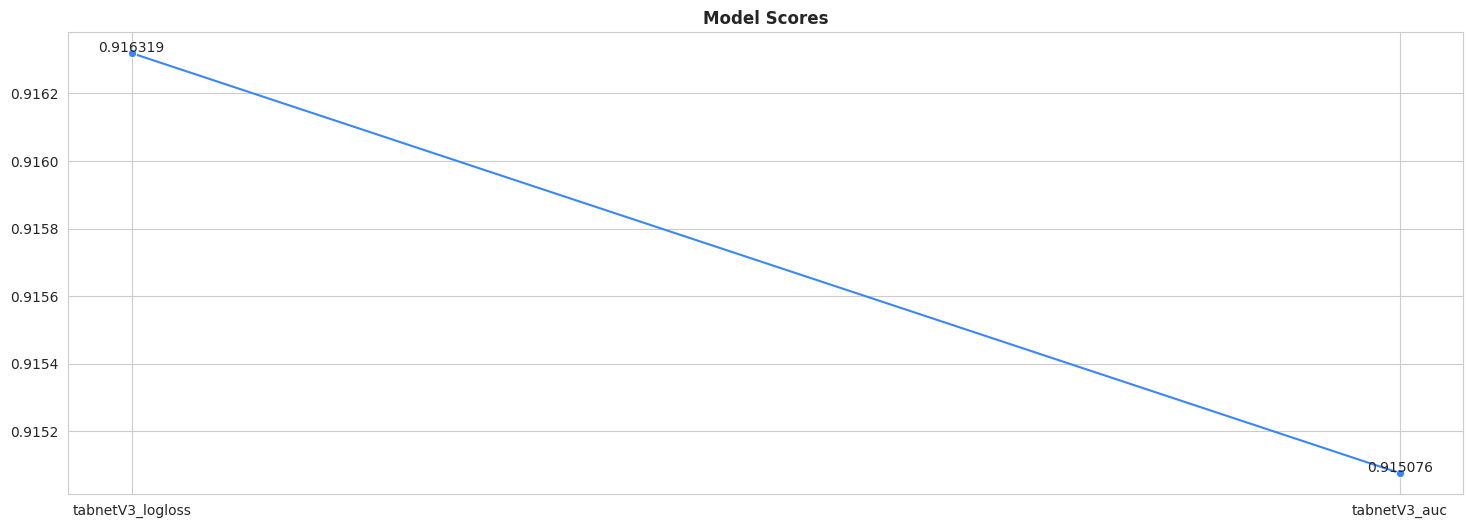

In [33]:
## -- Get models scores --
all_model_scores = {}

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y

plt.figure(figsize=(18, 6))
sns.lineplot(all_model_scores, marker='o')
# pd.Series(all_model_scores).plot(marker='o')
plt.title('Model Scores', fontweight='semibold')
plt.tick_params('x', rotation=0)

for i, score in enumerate(all_model_scores.values()):
    plt.text(float(i), score+2e-5, score, ha='center', va='center_baseline')

plt.show()

In [34]:
## -- Get oof predictions --
all_model_oof = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_oof = pd.concat([all_model_oof, pd.DataFrame({n: y})], axis=1)

all_model_oof.to_parquet(f"oof_{version_name}_models.parquet", index=False)
all_model_oof.head()

,tabnetV3_logloss_916319,tabnetV3_auc_915076
0,0.012994,0.019016
1,0.000897,0.001553
2,0.296362,0.205142
3,0.860683,0.809576
4,0.831068,0.872114


In [35]:
## -- Get test predictions --
all_model_test = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_test = pd.concat([all_model_test, pd.DataFrame({n: y})], axis=1)

all_model_test.to_parquet(f"test_{version_name}_models.parquet", index=False)
all_model_test.head()

,tabnetV3_logloss_916319,tabnetV3_auc_915076
0,0.110230,0.093821
1,0.001137,0.000968
2,0.131813,0.119483
3,0.003413,0.002459
4,0.516006,0.485262


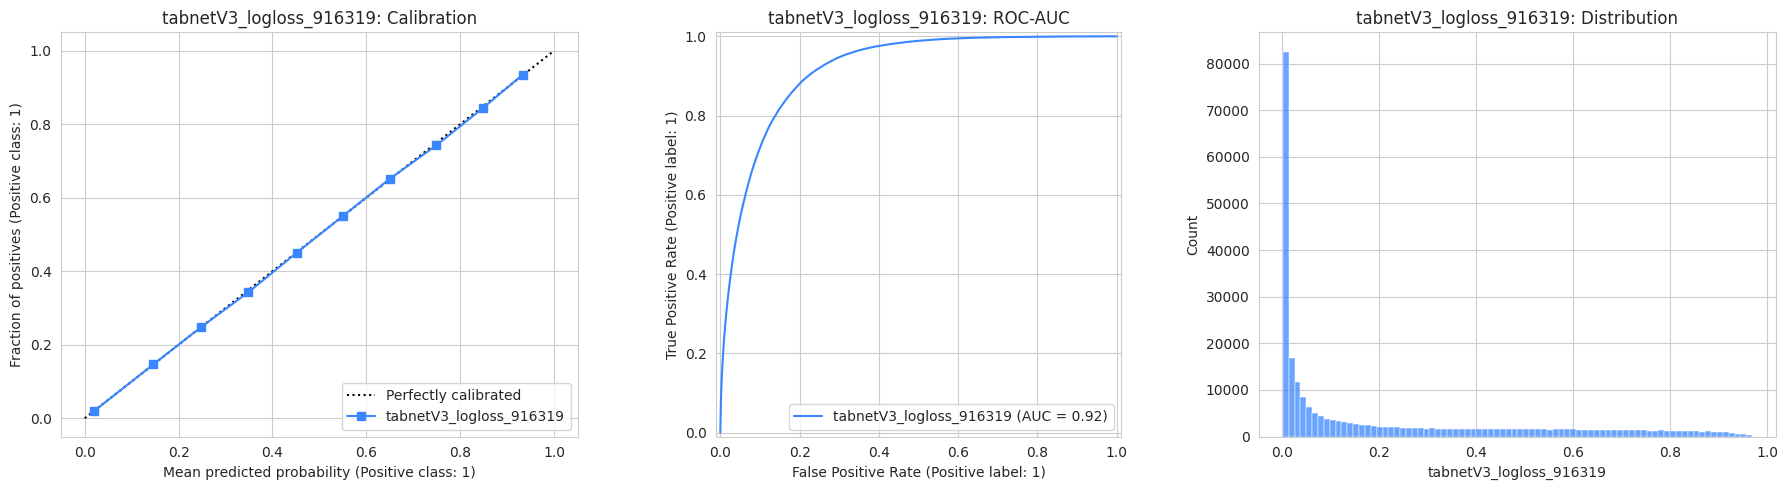

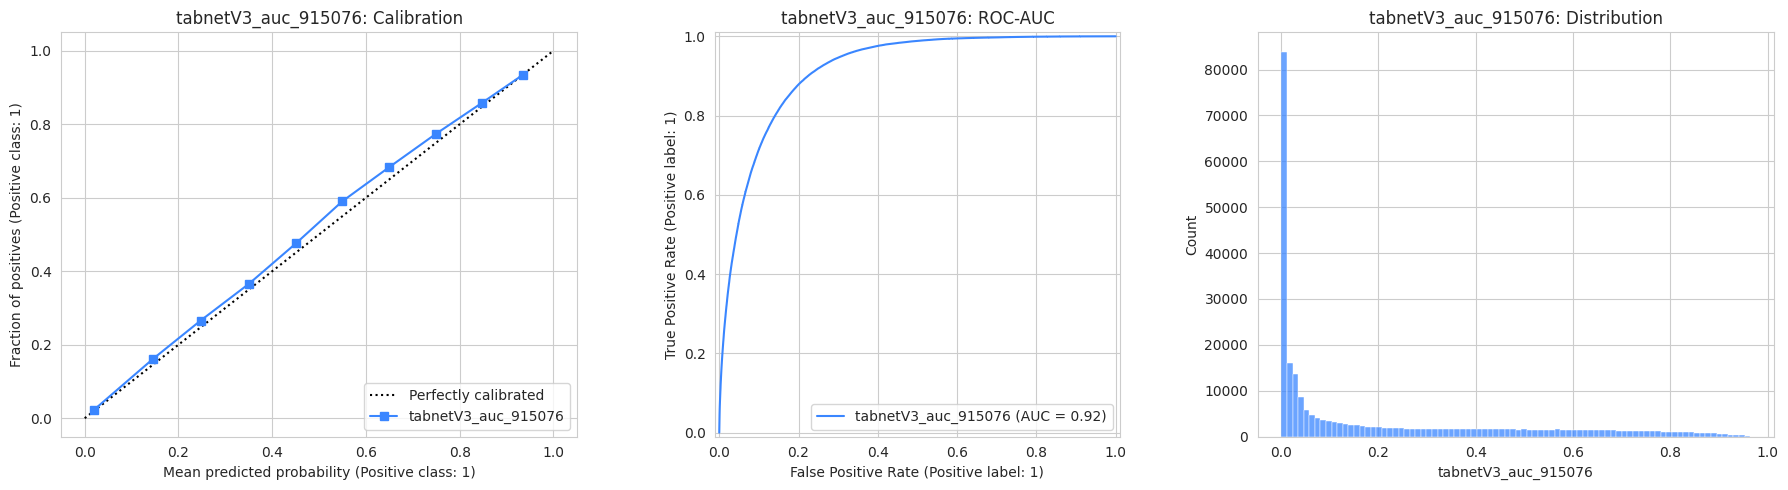

In [36]:
## -- PLOT PREDICTIONS --
for i, n in enumerate(all_model_test.columns):
    _, axs = plt.subplots(1, 3, figsize=(18, 5))

    CalibrationDisplay.from_predictions(train_data[TARGET], all_model_oof[n], n_bins=10, name=n, ax=axs[0])
    axs[0].set_title(f"{n}: Calibration")

    RocCurveDisplay.from_predictions(train_data[TARGET], all_model_oof[n], name=n, ax=axs[1])
    axs[1].set_title(f"{n}: ROC-AUC")
    # axs[1].grid(False)

    sns.histplot(all_model_test[n], ax=axs[2])
    axs[2].set_title(f"{n}: Distribution")

    plt.tight_layout()
    plt.show()
    print()

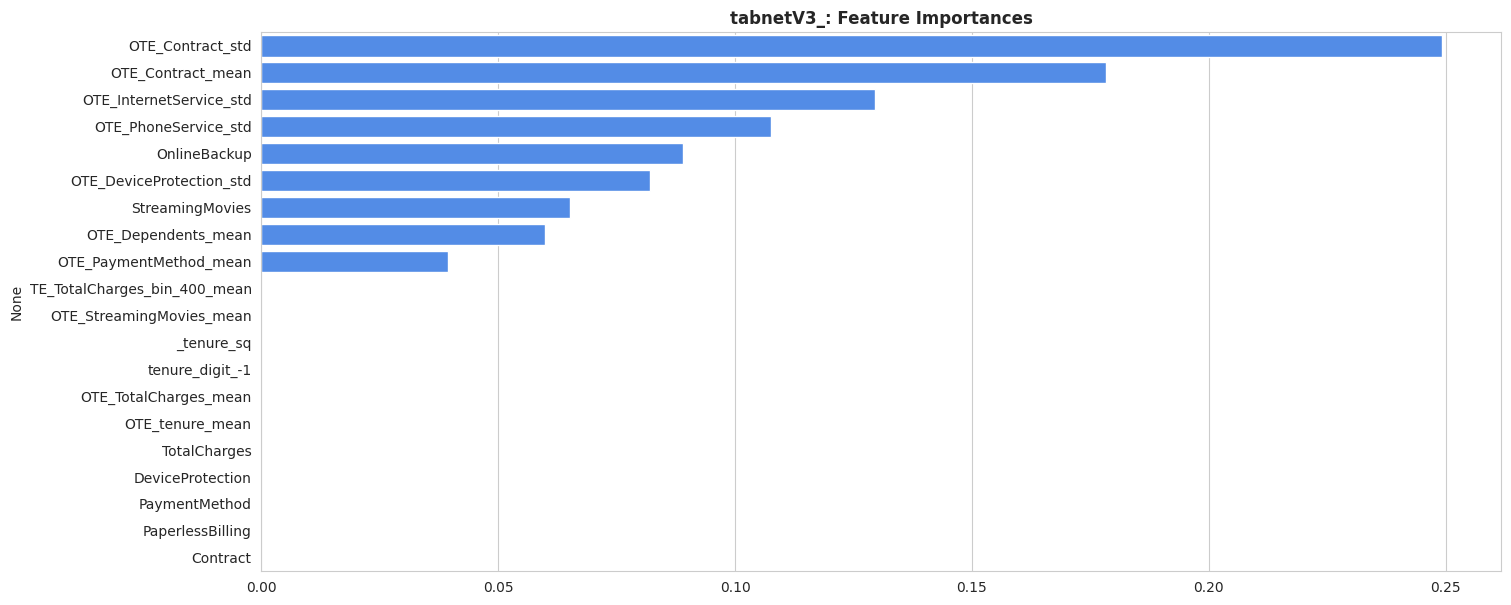

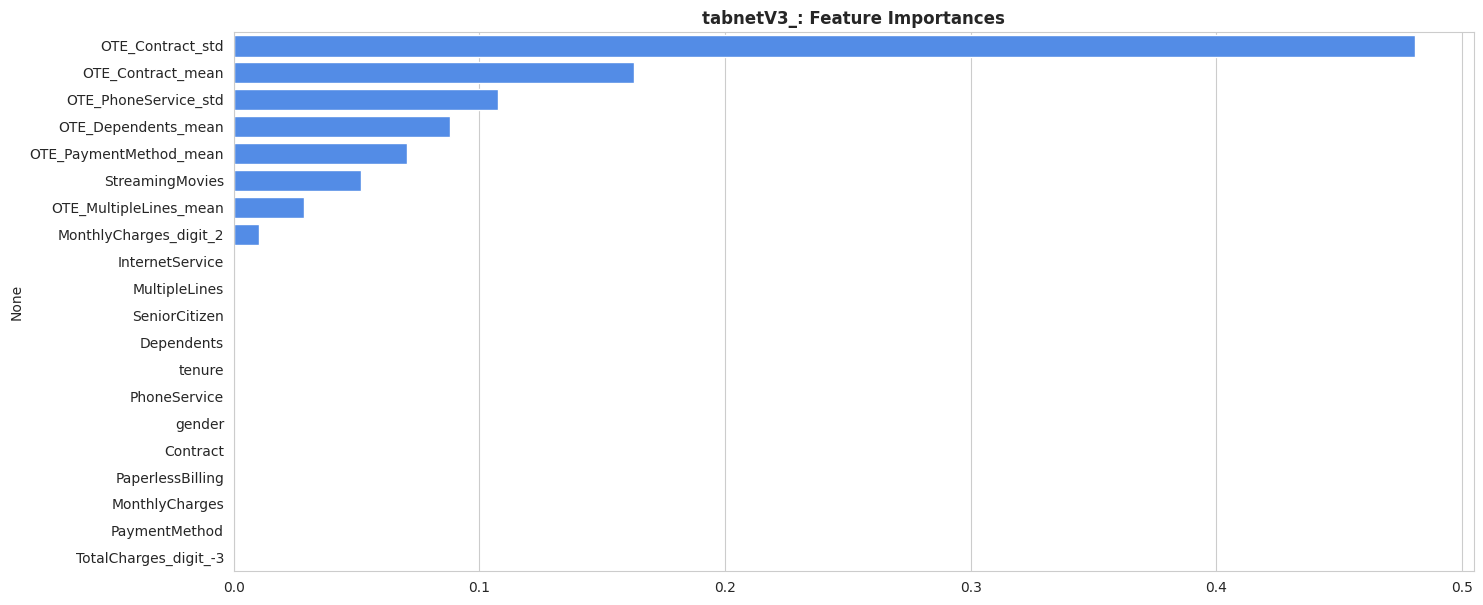

In [37]:
all_models = []

for i, _ in enumerate(list(all_model_predictions.keys())):
    model = all_model_predictions[list(all_model_predictions.keys())[i]]
    all_models.append(model)

## -- TabNet: FEATURE IMPORTANCES --
for m in all_models:
    feat_imp = m['model'].feature_importances_
    features = m['columns']
    df_temp  = pd.Series(dict(zip(features, feat_imp))).sort_values(ascending=False)[:20]

    plt.figure(figsize=(16, 7))
    sns.barplot(y=df_temp.index, x=df_temp.values)
    plt.title(f"{version_name}: Feature Importances", fontweight='semibold')

    # plt.tight_layout()
    plt.show()
    print()

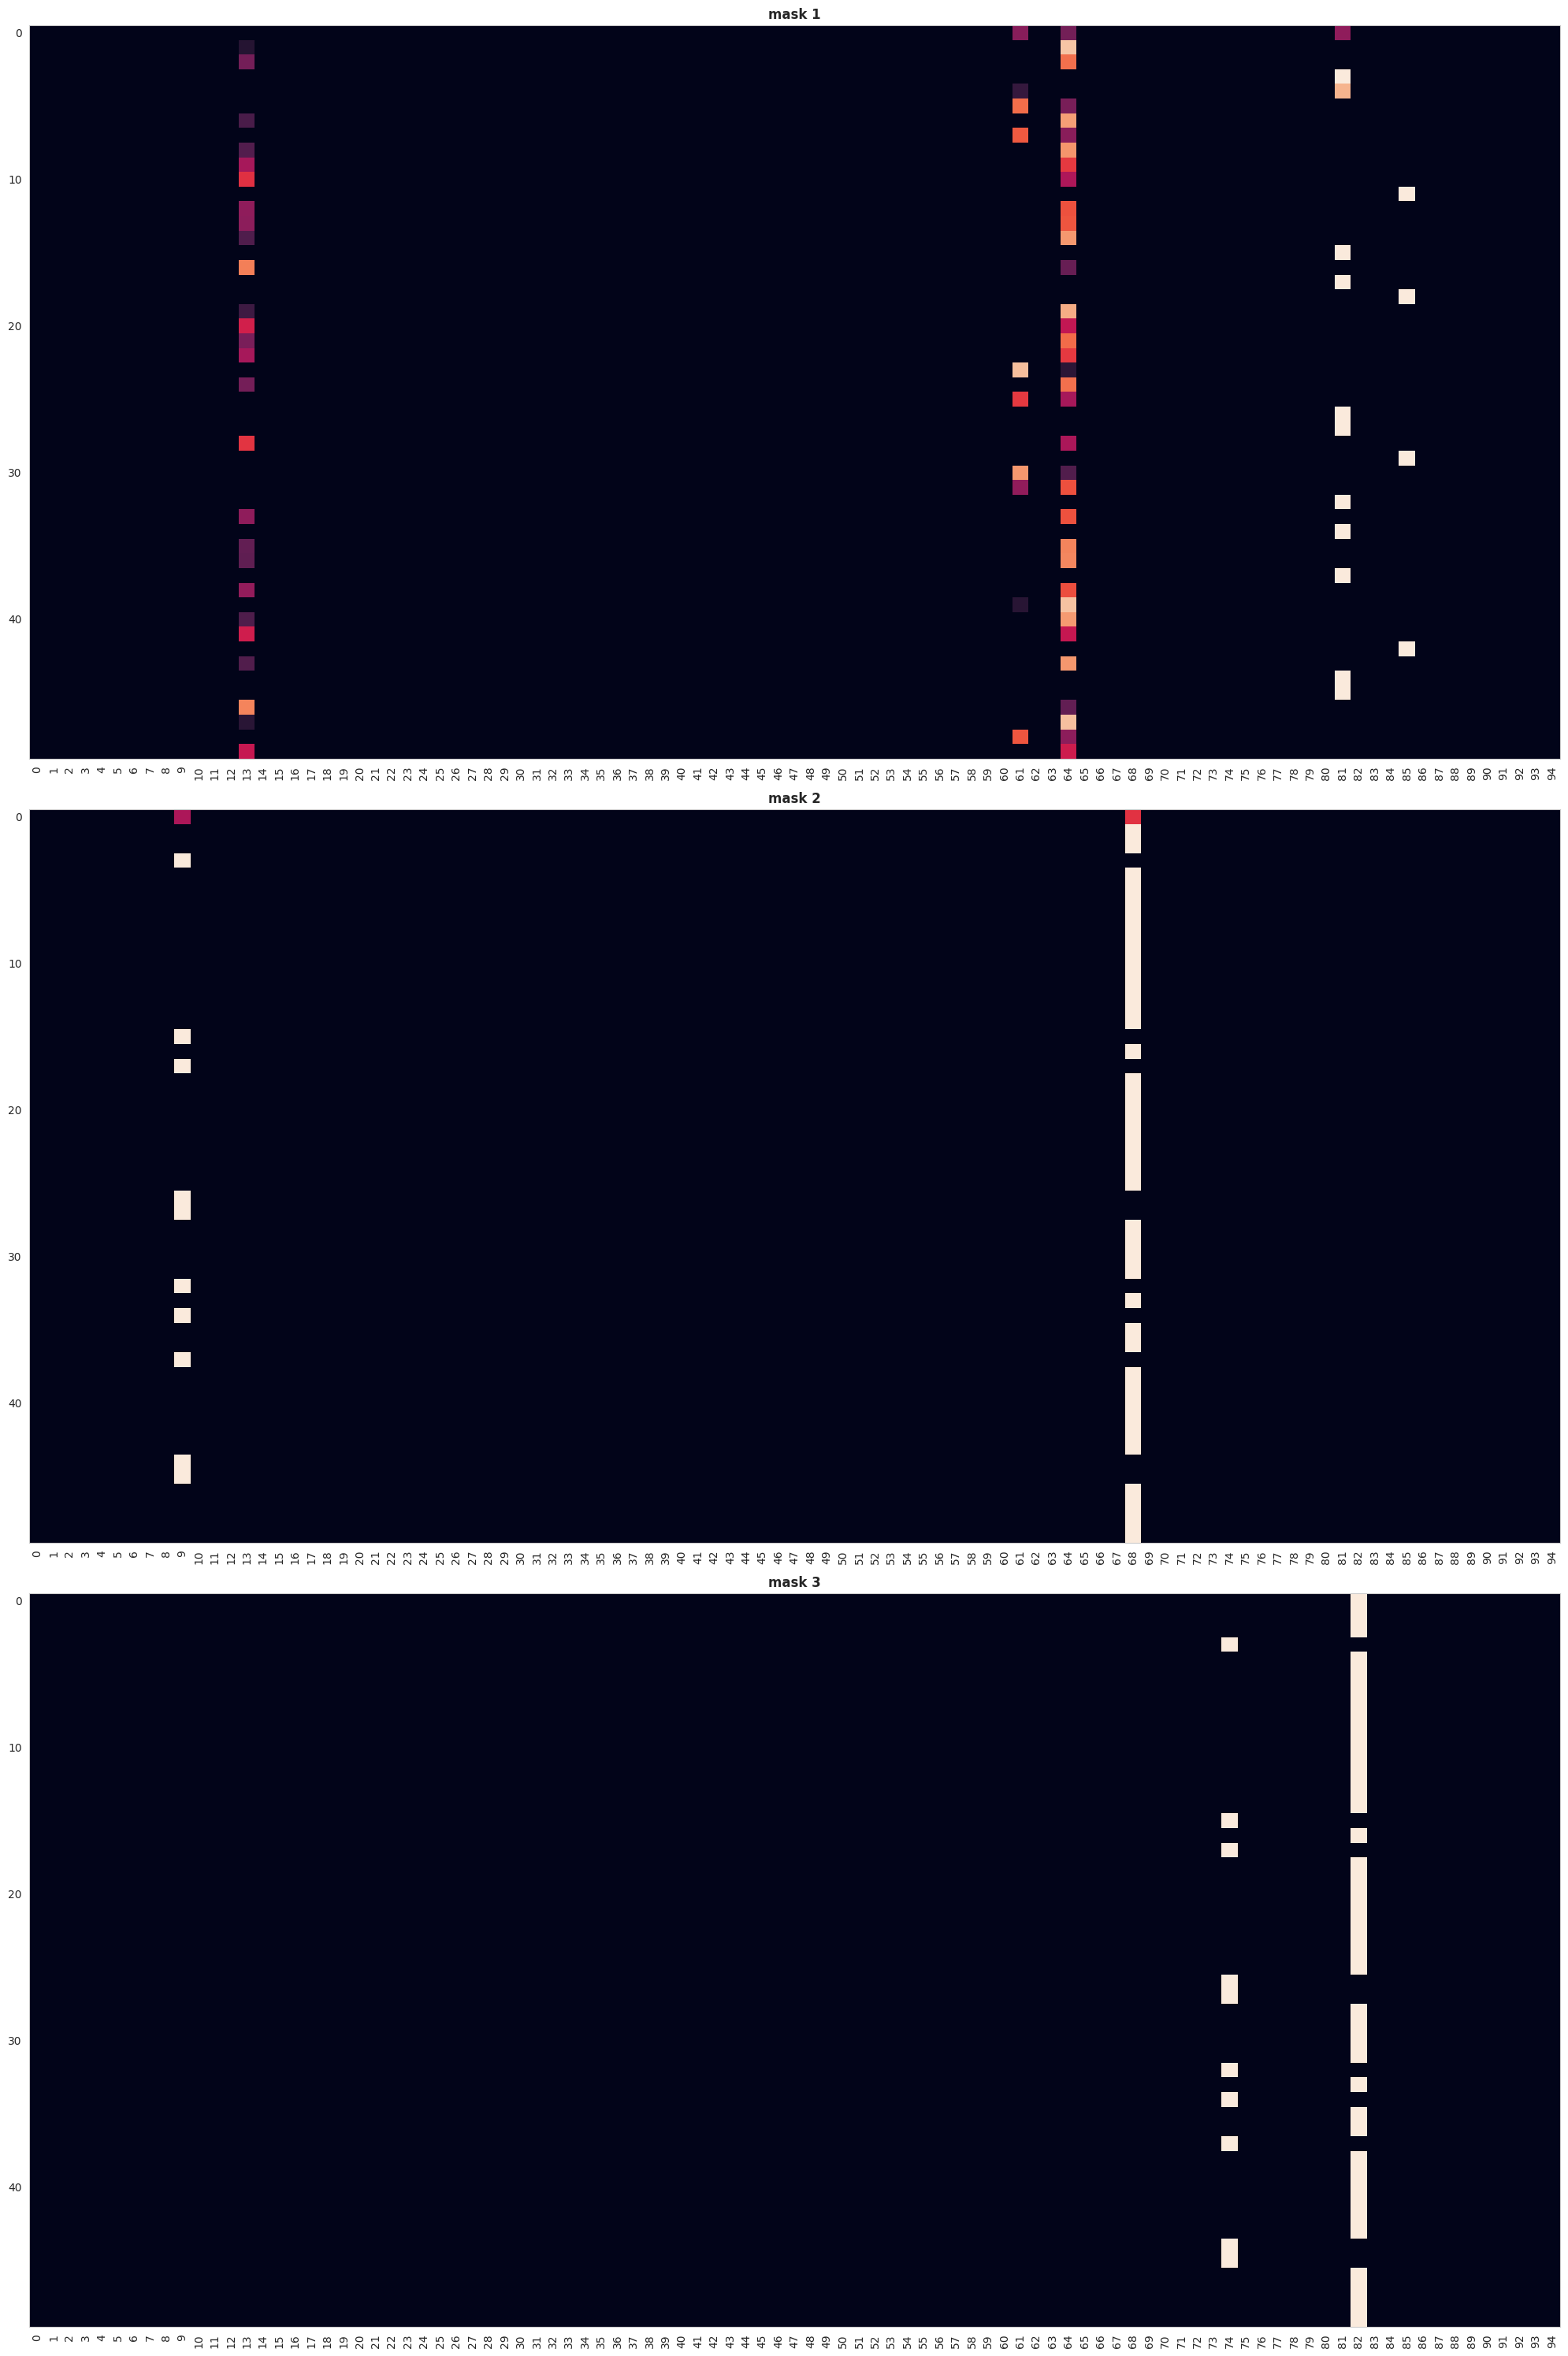

In [38]:
## -- MOST USED FEATURES --
explain_matrix, masks = all_models[0]['model'].explain(all_models[0]['val_data'].to_numpy())

plt.figure(figsize=(20, 30))
for i in range(3):
    ax = plt.subplot(3, 1, i+1)
    ax.imshow(masks[i][:50], aspect='auto')
    ax.set_title(f"mask {i+1}", weight='semibold')
    ax.set_xticks(range(len(all_models[0]['val_data'].columns)))
    ax.tick_params('x', rotation=90)
    ax.grid()
    
plt.tight_layout()
plt.show()